# BBC Articles Two-Stage Classification: Sport / Non-Sport -> Individual Sport

Hierarchical classification pipeline

how it works:

- Read ds
- Remove generic `/sport/articles/...` pages because they are not a single sport
- Stage 1: classify each article as `sport` or `non-sport`
- Stage 2: only for articles predicted as `sport`, classify the specific sport
- unify title + text = combined_text
- use train/validation/test splits for both stages

TEXT VECTORIZATION

it doesnt use the text as string BUT it converts it in numbers.

- lowercase, without accents, REMOVE 'the/and/is...'
- ngram_range=(1,2) -> single and couple worlds 'premier league, grand slam, rugby world cup...'
- makes common worls across every article weight less ('the/is...')
- makes topic-specific worlds weight MORE ('goal', 'wicket', 'serve', 'scrum', 'stock market'...)

PIPELINE IDEA:

- first model decides if the article is about sport at all
- second model specializes only on sport articles and predicts the single sport
- if stage 1 says `non-sport`, the pipeline stops there


## 1. Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# !pip install pandas scikit-learn matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from urllib.parse import urlparse

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load and view ds

In [4]:
DATA_PATH = '/content/drive/MyDrive/Dataset_Colab/bbc_articles_new_urls.csv'

df = pd.read_csv(DATA_PATH, sep=';')

print(f'Dataset shape: {df.shape}')
display(df.head(3))
print('\nOriginal category distribution:')
print(df['category'].value_counts())


Dataset shape: (7284, 4)


,title,text,category,url
0,Norwich's Sargent completes move to Toronto,Josh Sargent scored 56 goals in 157 appearance...,sport,https://www.bbc.com/sport/football/articles/c9...
1,Arsenal's Smith out of Canada squad with concu...,Olivia Smith started Arsenal's FA Cup fifth-ro...,sport,https://www.bbc.com/sport/football/articles/cd...
2,Gordon needs to stay 'fully focused' after Ars...,Anthony Gordon has scored 14 goals for Newcast...,sport,https://www.bbc.com/sport/football/articles/cn...



Original category distribution:
category
sport            2490
non-sport        1000
business          808
politics          718
entertainment     687
tech              687
science           300
health            298
world             296
Name: count, dtype: int64


## 3. Targets and text preparation

In [5]:
def extract_sport_label(url):
    if pd.isna(url) or not isinstance(url, str):
        return np.nan


    if not url.strip():
        return np.nan

    parts = [part for part in urlparse(url).path.split('/') if part]
    if len(parts) >= 2 and parts[0] == 'sport':
        return parts[1]
    return np.nan


df = df[df['category'].isin(['sport', 'non-sport'])].copy()
df['title'] = df['title'].fillna('')
df['text'] = df['text'].fillna('')
df['combined_text'] = (df['title'] + ' ' + df['text']).str.strip()

df['sport_label'] = np.where(
    df['category'] == 'sport',
    df['url'].apply(extract_sport_label),
    'non-sport'
)

# remove generic BBC sport landing pages because they are not a single sport class
df = df[df['sport_label'].notna()].copy()
df = df[df['sport_label'] != 'articles'].copy()

df['binary_label'] = df['category'].map({'non-sport': 0, 'sport': 1})
df['final_label'] = np.where(df['category'] == 'sport', df['sport_label'], 'non-sport')

sport_class_counts = df[df['category'] == 'sport']['sport_label'].value_counts().sort_values(ascending=False)

print(f'Rows kept after cleanup: {len(df)}')
print('\nBinary distribution:')
print(df['category'].value_counts())
print('\nSport distribution:')
print(sport_class_counts)
print('\nEmpty combined_text rows:', (df['combined_text'].str.len() == 0).sum())


Rows kept after cleanup: 3457

Binary distribution:
category
sport        2457
non-sport    1000
Name: count, dtype: int64

Sport distribution:
sport_label
football              798
athletics             389
rugby-union           297
tennis                264
cricket               257
formula1              157
boxing                131
golf                   65
cycling                51
netball                22
olympics                7
ice-hockey              6
rugby-league            5
snooker                 4
mixed-martial-arts      2
swimming                1
motorsport              1
Name: count, dtype: int64

Empty combined_text rows: 0


## 4. Train / Validation / Test Split

In [6]:
def split_single_class(group, random_state=RANDOM_STATE):
    shuffled = group.sample(frac=1, random_state=random_state)
    n = len(shuffled)

    if n == 1:
        train_n, val_n, test_n = 1, 0, 0
    elif n == 2:
        train_n, val_n, test_n = 1, 0, 1
    elif n == 3:
        train_n, val_n, test_n = 1, 1, 1
    elif n == 4:
        train_n, val_n, test_n = 2, 1, 1
    else:
        val_n = max(1, int(round(n * 0.20)))
        test_n = max(1, int(round(n * 0.20)))
        train_n = n - val_n - test_n

        if train_n < 1:
            train_n = 1
            if val_n >= test_n and val_n > 1:
                val_n -= 1
            else:
                test_n -= 1

    train_split = shuffled.iloc[:train_n]
    val_split = shuffled.iloc[train_n:train_n + val_n]
    test_split = shuffled.iloc[train_n + val_n:train_n + val_n + test_n]

    return train_split, val_split, test_split


# split non-sport with a standard stratified split
non_sport_df = df[df['category'] == 'non-sport'].copy()
ns_train_val, ns_test = train_test_split(
    non_sport_df,
    test_size=0.20,
    random_state=RANDOM_STATE
)
ns_train, ns_val = train_test_split(
    ns_train_val,
    test_size=0.25,
    random_state=RANDOM_STATE
)

# split sport per single sport so every discovered sport stays in training
sport_df = df[df['category'] == 'sport'].copy()
sport_train_parts = []
sport_val_parts = []
sport_test_parts = []

for _, group in sport_df.groupby('sport_label', sort=False):
    train_part, val_part, test_part = split_single_class(group)
    sport_train_parts.append(train_part)
    if len(val_part) > 0:
        sport_val_parts.append(val_part)
    if len(test_part) > 0:
        sport_test_parts.append(test_part)

sport_train_df = pd.concat(sport_train_parts)
sport_val_df = pd.concat(sport_val_parts)
sport_test_df = pd.concat(sport_test_parts)

# final splits used by stage 1 (binary)
train_df = pd.concat([ns_train, sport_train_df]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
val_df = pd.concat([ns_val, sport_val_df]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
test_df = pd.concat([ns_test, sport_test_df]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f'Train size: {len(train_df)}')
print(f'Validation size: {len(val_df)}')
print(f'Test size: {len(test_df)}')

print('\nTrain binary balance:')
print(train_df['category'].value_counts())
print('\nValidation binary balance:')
print(val_df['category'].value_counts())
print('\nTest binary balance:')
print(test_df['category'].value_counts())

print('\nTrain sport balance:')
print(sport_train_df['sport_label'].value_counts())
print('\nValidation sport balance:')
print(sport_val_df['sport_label'].value_counts())
print('\nTest sport balance:')
print(sport_test_df['sport_label'].value_counts())


Train size: 2078
Validation size: 689
Test size: 690

Train binary balance:
category
sport        1478
non-sport     600
Name: count, dtype: int64

Validation binary balance:
category
sport        489
non-sport    200
Name: count, dtype: int64

Test binary balance:
category
sport        490
non-sport    200
Name: count, dtype: int64

Train sport balance:
sport_label
football              478
athletics             233
rugby-union           179
tennis                158
cricket               155
formula1               95
boxing                 79
golf                   39
cycling                31
netball                14
olympics                5
ice-hockey              4
rugby-league            3
snooker                 2
swimming                1
mixed-martial-arts      1
motorsport              1
Name: count, dtype: int64

Validation sport balance:
sport_label
football        160
athletics        78
rugby-union      59
tennis           53
cricket          51
formula1         31
boxi

## 5. Stage 1: Sport vs Non-Sport

In [7]:
X_train_bin = train_df['combined_text']
y_train_bin = train_df['binary_label']

X_val_bin = val_df['combined_text']
y_val_bin = val_df['binary_label']

X_test_bin = test_df['combined_text']
y_test_bin = test_df['binary_label']

### Option A: TF-IDF

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

binary_vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents='unicode',
    stop_words='english',
    ngram_range=(1, 2),
    max_features=30000,
    min_df=2
)

X_train_bin_vec = binary_vectorizer.fit_transform(X_train_bin)
X_val_bin_vec   = binary_vectorizer.transform(X_val_bin)
X_test_bin_vec  = binary_vectorizer.transform(X_test_bin)

VECTORIZER_TYPE = 'TF-IDF'
print(f'[{VECTORIZER_TYPE}] Train shape: {X_train_bin_vec.shape}')
print(f'[{VECTORIZER_TYPE}] Val   shape: {X_val_bin_vec.shape}')
print(f'[{VECTORIZER_TYPE}] Test  shape: {X_test_bin_vec.shape}')

[TF-IDF] Train shape: (2078, 30000)
[TF-IDF] Val   shape: (689, 30000)
[TF-IDF] Test  shape: (690, 30000)


In [9]:
!pip install --upgrade gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 78.6 MB/s eta 0:00:00


### Option B: Word2Vec

In [10]:
import re
import numpy as np
import gensim.downloader as gensim_api

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

_stop_en = set(stopwords.words('english'))

def _tokenize(text: str) -> list[str]:
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return [t for t in text.split() if t not in _stop_en and len(t) > 1]

def _docs_to_matrix_pretrained(texts, model, vector_size: int) -> np.ndarray:
    rows = []
    for text in texts:
        tokens = _tokenize(text)
        vecs = [model[t] for t in tokens if t in model]
        rows.append(np.mean(vecs, axis=0) if vecs else np.zeros(vector_size))
    return np.array(rows)

print('Loading fastText model...')
ft_model = gensim_api.load('fasttext-wiki-news-subwords-300')
W2V_VECTOR_SIZE = 300

X_train_bin_vec = _docs_to_matrix_pretrained(X_train_bin, ft_model, W2V_VECTOR_SIZE)
X_val_bin_vec   = _docs_to_matrix_pretrained(X_val_bin,   ft_model, W2V_VECTOR_SIZE)
X_test_bin_vec  = _docs_to_matrix_pretrained(X_test_bin,  ft_model, W2V_VECTOR_SIZE)

VECTORIZER_TYPE = 'fastText pretrained (300d)'
print(f'[{VECTORIZER_TYPE}] Train shape: {X_train_bin_vec.shape}')
print(f'[{VECTORIZER_TYPE}] Val   shape: {X_val_bin_vec.shape}')
print(f'[{VECTORIZER_TYPE}] Test  shape: {X_test_bin_vec.shape}')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Loading fastText model...
[================================------------------] 64.8% 621.0/958.4MB downloaded

KeyboardInterrupt: 

In [13]:
binary_mlp = MLPClassifier(
    hidden_layer_sizes=(256, 64),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=1,
    warm_start=True,
    random_state=RANDOM_STATE
)

EPOCHS = 20
binary_train_acc_history = []
binary_val_acc_history = []

for epoch in range(EPOCHS):
    binary_mlp.fit(X_train_bin_vec, y_train_bin)

    train_pred = binary_mlp.predict(X_train_bin_vec)
    val_pred = binary_mlp.predict(X_val_bin_vec)

    train_acc = accuracy_score(y_train_bin, train_pred)
    val_acc = accuracy_score(y_val_bin, val_pred)

    binary_train_acc_history.append(train_acc)
    binary_val_acc_history.append(val_acc)

print(f'[{VECTORIZER_TYPE}] Stage 1 - Epoch {epoch+1:02d}/{EPOCHS} '
          f'- Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}')


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691

[TF-IDF] Stage 1 - Epoch 20/20 - Train Acc: 1.0000 - Val Acc: 0.9826


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691

[TF-IDF] Stage 1 - Epoch 20/20 - Train Acc: 1.0000 - Val Acc: 0.9826


Best stage 1 validation accuracy: 0.9840 at epoch 6


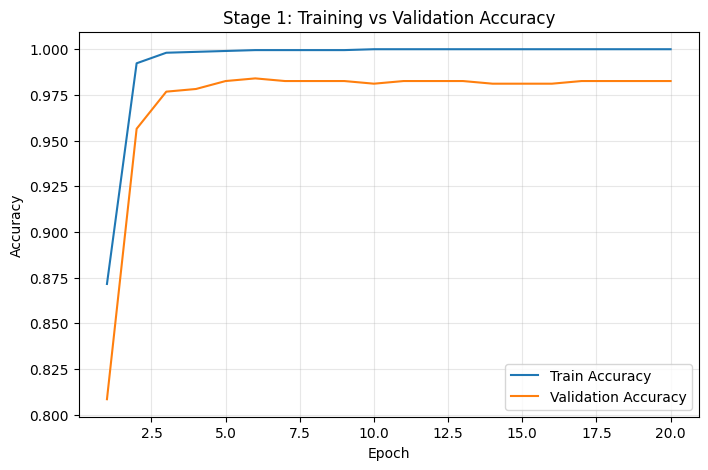

Best stage 1 validation accuracy: 0.9840 at epoch 6


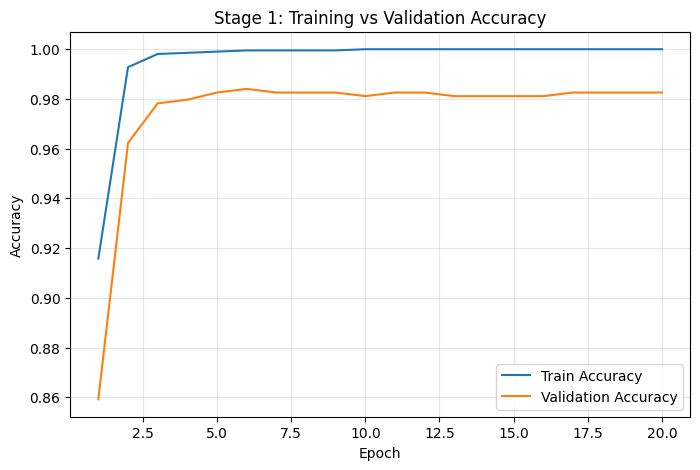

In [14]:
best_binary_epoch = int(np.argmax(binary_val_acc_history))
best_binary_val_acc = binary_val_acc_history[best_binary_epoch]

print(f'Best stage 1 validation accuracy: {best_binary_val_acc:.4f} at epoch {best_binary_epoch + 1}')

plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), binary_train_acc_history, label='Train Accuracy')
plt.plot(range(1, EPOCHS + 1), binary_val_acc_history, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Stage 1: Training vs Validation Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
y_test_bin_pred = binary_mlp.predict(X_test_bin_vec)

test_acc = accuracy_score(y_test_bin, y_test_bin_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test_bin,
    y_test_bin_pred,
    average='binary',
    zero_division=0
)

print(f'Stage 1 Test Accuracy : {test_acc:.4f}')
print(f'Stage 1 Test Precision: {precision:.4f}')
print(f'Stage 1 Test Recall   : {recall:.4f}')
print(f'Stage 1 Test F1-score : {f1:.4f}')

print("=============================================================")
print(f'[{VECTORIZER_TYPE}] Stage 1')
print('\nDetailed classification report:')
print()
print(classification_report(y_test_bin, y_test_bin_pred, target_names=['Non-Sport', 'Sport'], zero_division=0))

cm = confusion_matrix(y_test_bin, y_test_bin_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Sport', 'Sport'],
    yticklabels=['Non-Sport', 'Sport']
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Stage 1 Confusion Matrix (Test Set)')
plt.show()


## 6. Stage 2: Individual Sport Classification

In [15]:
sport_class_names = sorted(sport_df['sport_label'].unique())
sport_label_to_id = {label: idx for idx, label in enumerate(sport_class_names)}
sport_id_to_label = {idx: label for label, idx in sport_label_to_id.items()}

sport_train_df = sport_train_df.copy()
sport_val_df = sport_val_df.copy()
sport_test_df = sport_test_df.copy()

sport_train_df['sport_id'] = sport_train_df['sport_label'].map(sport_label_to_id)
sport_val_df['sport_id'] = sport_val_df['sport_label'].map(sport_label_to_id)
sport_test_df['sport_id'] = sport_test_df['sport_label'].map(sport_label_to_id)

X_train_sport = sport_train_df['combined_text']
y_train_sport = sport_train_df['sport_id']

X_val_sport = sport_val_df['combined_text']
y_val_sport = sport_val_df['sport_id']

X_test_sport = sport_test_df['combined_text']
y_test_sport = sport_test_df['sport_id']



In [ ]:
#  OPTION A: TF-IDF
sport_vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents='unicode',
    stop_words='english',
    ngram_range=(1, 2),
    max_features=30000,
    min_df=2
)

X_train_sport_vec = sport_vectorizer.fit_transform(X_train_sport)
X_val_sport_vec   = sport_vectorizer.transform(X_val_sport)
X_test_sport_vec  = sport_vectorizer.transform(X_test_sport)

SPORT_VECTORIZER_TYPE = 'TF-IDF'
print(f'[{SPORT_VECTORIZER_TYPE}] Train shape: {X_train_sport_vec.shape}')
print(f'[{SPORT_VECTORIZER_TYPE}] Val   shape: {X_val_sport_vec.shape}')
print(f'[{SPORT_VECTORIZER_TYPE}] Test  shape: {X_test_sport_vec.shape}')

In [ ]:
# OPTION B: Word2Vec

X_train_sport_vec = _docs_to_matrix_pretrained(X_train_sport, ft_model, W2V_VECTOR_SIZE)
X_val_sport_vec = _docs_to_matrix_pretrained(X_val_sport,   ft_model, W2V_VECTOR_SIZE)
X_test_sport_vec = _docs_to_matrix_pretrained(X_test_sport,  ft_model, W2V_VECTOR_SIZE)

SPORT_VECTORIZER_TYPE = 'fastText pretrained (300d)'
print(f'[{SPORT_VECTORIZER_TYPE}] Train shape: {X_train_sport_vec.shape}')
print(f'[{SPORT_VECTORIZER_TYPE}] Val   shape: {X_val_sport_vec.shape}')
print(f'[{SPORT_VECTORIZER_TYPE}] Test  shape: {X_test_sport_vec.shape}')

In [ ]:
sport_mlp = MLPClassifier(
    hidden_layer_sizes=(256, 64),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=1,
    warm_start=True,
    random_state=RANDOM_STATE
)

sport_train_acc_history = []
sport_val_acc_history = []

print("=============================================================")
print(f'[{SPORT_VECTORIZER_TYPE}] Starting Stage 2 training...')

for epoch in range(EPOCHS):
    sport_mlp.fit(X_train_sport_vec, y_train_sport)

    train_pred = sport_mlp.predict(X_train_sport_vec)
    val_pred = sport_mlp.predict(X_val_sport_vec)

    train_acc = accuracy_score(y_train_sport, train_pred)
    val_acc = accuracy_score(y_val_sport, val_pred)

    sport_train_acc_history.append(train_acc)
    sport_val_acc_history.append(val_acc)

    print(f'Stage 2 - Epoch {epoch + 1:02d}/{EPOCHS} - Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}')



In [ ]:
best_sport_epoch = int(np.argmax(sport_val_acc_history))
best_sport_val_acc = sport_val_acc_history[best_sport_epoch]

print(f'Best stage 2 validation accuracy: {best_sport_val_acc:.4f} at epoch {best_sport_epoch + 1}')

plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), sport_train_acc_history, label='Train Accuracy')
plt.plot(range(1, EPOCHS + 1), sport_val_acc_history, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Stage 2: Training vs Validation Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
y_test_sport_pred = sport_mlp.predict(X_test_sport_vec)

test_acc = accuracy_score(y_test_sport, y_test_sport_pred)
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_test_sport,
    y_test_sport_pred,
    average='macro',
    zero_division=0
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_test_sport,
    y_test_sport_pred,
    average='weighted',
    zero_division=0
)

print(f'Stage 2 Test Accuracy        : {test_acc:.4f}')
print(f'Stage 2 Test Precision Macro : {precision_macro:.4f}')
print(f'Stage 2 Test Recall Macro    : {recall_macro:.4f}')
print(f'Stage 2 Test F1-score Macro  : {f1_macro:.4f}')
print(f'Stage 2 Test Precision Weight: {precision_weighted:.4f}')
print(f'Stage 2 Test Recall Weight   : {recall_weighted:.4f}')
print(f'Stage 2 Test F1-score Weight : {f1_weighted:.4f}')

labels_in_test = sorted(y_test_sport.unique())
target_names_in_test = [sport_id_to_label[label] for label in labels_in_test]

print('\nDetailed classification report:')
print(
    classification_report(
        y_test_sport,
        y_test_sport_pred,
        labels=labels_in_test,
        target_names=target_names_in_test,
        zero_division=0
    )
)

cm = confusion_matrix(y_test_sport, y_test_sport_pred, labels=labels_in_test)
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names_in_test,
    yticklabels=target_names_in_test
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Stage 2 Confusion Matrix (Test Set)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 7. End-to-End Pipeline Evaluation

In [ ]:
def predict_pipeline(texts):
    if VECTORIZER_TYPE == 'TF-IDF':
        binary_features = binary_vectorizer.transform(texts)
    else:
        binary_features = _docs_to_matrix_pretrained(texts, ft_model, W2V_VECTOR_SIZE)

    binary_preds = binary_mlp.predict(binary_features)

    final_preds = []
    for text, binary_pred in zip(texts, binary_preds):
        if binary_pred == 0:
            final_preds.append('non-sport')
        else:
            if SPORT_VECTORIZER_TYPE == 'TF-IDF':
                sport_features = sport_vectorizer.transform([text])
            else:  # fastText pretrained (300d)
                sport_features = _docs_to_matrix_pretrained([text], ft_model, W2V_VECTOR_SIZE)

            sport_pred = sport_mlp.predict(sport_features)[0]
            final_preds.append(sport_id_to_label[sport_pred])

    return final_preds, binary_preds


print("=============================================================")
print(f'[{SPORT_VECTORIZER_TYPE}]')
pipeline_test_preds, binary_test_preds = predict_pipeline(test_df['combined_text'])
pipeline_test_true = test_df['final_label'].tolist()

pipeline_acc = accuracy_score(pipeline_test_true, pipeline_test_preds)
pipeline_precision_macro, pipeline_recall_macro, pipeline_f1_macro, _ = precision_recall_fscore_support(
    pipeline_test_true,
    pipeline_test_preds,
    average='macro',
    zero_division=0
)
pipeline_precision_weighted, pipeline_recall_weighted, pipeline_f1_weighted, _ = precision_recall_fscore_support(
    pipeline_test_true,
    pipeline_test_preds,
    average='weighted',
    zero_division=0
)

print(f'Pipeline Test Accuracy        : {pipeline_acc:.4f}')
print(f'Pipeline Test Precision Macro : {pipeline_precision_macro:.4f}')
print(f'Pipeline Test Recall Macro    : {pipeline_recall_macro:.4f}')
print(f'Pipeline Test F1-score Macro  : {pipeline_f1_macro:.4f}')
print(f'Pipeline Test Precision Weight: {pipeline_precision_weighted:.4f}')
print(f'Pipeline Test Recall Weight   : {pipeline_recall_weighted:.4f}')
print(f'Pipeline Test F1-score Weight : {pipeline_f1_weighted:.4f}')

pipeline_labels = ['non-sport'] + sport_class_names
print('\nDetailed pipeline classification report:')
print(classification_report(pipeline_test_true, pipeline_test_preds, labels=pipeline_labels, zero_division=0))


## 8. Try New Examples

In [ ]:
new_samples = [
    'Manchester United won 3-1 with a late goal in the Premier League.',
    'The batter scored a century after a dominant opening partnership in the second innings.',
    'The driver secured pole position and managed tyre wear perfectly over the final laps.',
    'She broke serve twice to win the second set and reach the quarter-final.',
    'Donald Trump just died in his house in Florida.',
    'Bankrupt company announces restructuring plan for next quarter.'
]

pipeline_preds, stage1_preds = predict_pipeline(new_samples)
stage1_probs = binary_mlp.predict_proba(binary_vectorizer.transform(new_samples))[:, 1]

for text, stage1_pred, stage1_prob, final_pred in zip(new_samples, stage1_preds, stage1_probs, pipeline_preds):
    stage1_label = 'sport' if stage1_pred == 1 else 'non-sport'
    print(f'Text: {text}')
    print(f'Stage 1 prediction: {stage1_label} (sport probability={stage1_prob:.3f})')
    print(f'Final pipeline label: {final_pred}')
    print('-' * 80)


# 8. BERT


In [ ]:
!pip install transformers torch scikit-learn

In [18]:
# Fine-tuning BERT per classificazione sport specifico

!pip install transformers datasets -q

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# Config
MODEL_NAME   = "bert-base-uncased"
MAX_LEN      = 256        # titolo + testo tende ad essere lungo
BATCH_SIZE   = 16
EPOCHS       = 4
LR           = 2e-5
WARMUP_RATIO = 0.1
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES  = len(sport_class_names)

print(f"Device: {DEVICE} | Classi sport: {NUM_CLASSES} → {sport_class_names}")

# Dataset
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

class SportDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts.reset_index(drop=True)
        self.labels    = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(int(self.labels[idx]), dtype=torch.long),
        }

train_ds = SportDataset(X_train_sport, y_train_sport, tokenizer, MAX_LEN)
val_ds   = SportDataset(X_val_sport,   y_val_sport,   tokenizer, MAX_LEN)
test_ds  = SportDataset(X_test_sport,  y_test_sport,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Modello
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    id2label=sport_id_to_label,
    label2id=sport_label_to_id,
)
model.to(DEVICE)

# Optimizer + Scheduler
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

# Training loop
def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for batch in tqdm(loader, leave=False):
            ids   = batch["input_ids"].to(DEVICE)
            mask  = batch["attention_mask"].to(DEVICE)
            lbls  = batch["labels"].to(DEVICE)

            out  = model(input_ids=ids, attention_mask=mask, labels=lbls)
            loss = out.loss

            if training:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

            total_loss += loss.item() * ids.size(0)
            preds       = out.logits.argmax(dim=-1)
            correct    += (preds == lbls).sum().item()
            total      += ids.size(0)

    return total_loss / total, correct / total


history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    vl_loss, vl_acc = run_epoch(val_loader,   training=False)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    print(f"Epoch {epoch}/{EPOCHS}  "
          f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  "
          f"val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}")

# Evaluation su test set
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test"):
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        lbls = batch["labels"].to(DEVICE)

        logits = model(input_ids=ids, attention_mask=mask).logits
        preds  = logits.argmax(dim=-1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(lbls.cpu().numpy())

model.save_pretrained("./bert_sport_stage2")
tokenizer.save_pretrained("./bert_sport_stage2")
print("Modello salvato in ./bert_sport_stage2")




Device: cuda | Classi sport: 17 → ['athletics', 'boxing', 'cricket', 'cycling', 'football', 'formula1', 'golf', 'ice-hockey', 'mixed-martial-arts', 'motorsport', 'netball', 'olympics', 'rugby-league', 'rugby-union', 'snooker', 'swimming', 'tennis']


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  0%|          | 0/93 [00:00<?, ?it/s]

  0%|          | 0/31 [00:00<?, ?it/s]

...

  0%|          | 0/31 [00:00<?, ?it/s]

Epoch 4/4  train_loss=0.3115  train_acc=0.9411  val_loss=0.4988  val_acc=0.8712


Test:   0%|          | 0/31 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modello salvato in ./bert_sport_stage2


Nota: il modello pretrained è stato salvato su drive. Lo si può recuperare


── Classification Report ──
                    precision    recall  f1-score   support

         athletics       0.83      0.90      0.86        78
            boxing       0.86      0.69      0.77        26
           cricket       0.98      0.90      0.94        51
           cycling       0.90      0.90      0.90        10
          football       0.85      0.89      0.87       160
          formula1       0.88      0.94      0.91        31
              golf       0.93      1.00      0.96        13
        ice-hockey       0.00      0.00      0.00         1
mixed-martial-arts       0.00      0.00      0.00         1
           netball       1.00      0.25      0.40         4
          olympics       0.00      0.00      0.00         1
      rugby-league       0.00      0.00      0.00         1
       rugby-union       0.85      0.90      0.88        59
           snooker       0.00      0.00      0.00         1
            tennis       0.96      0.91      0.93        53

         

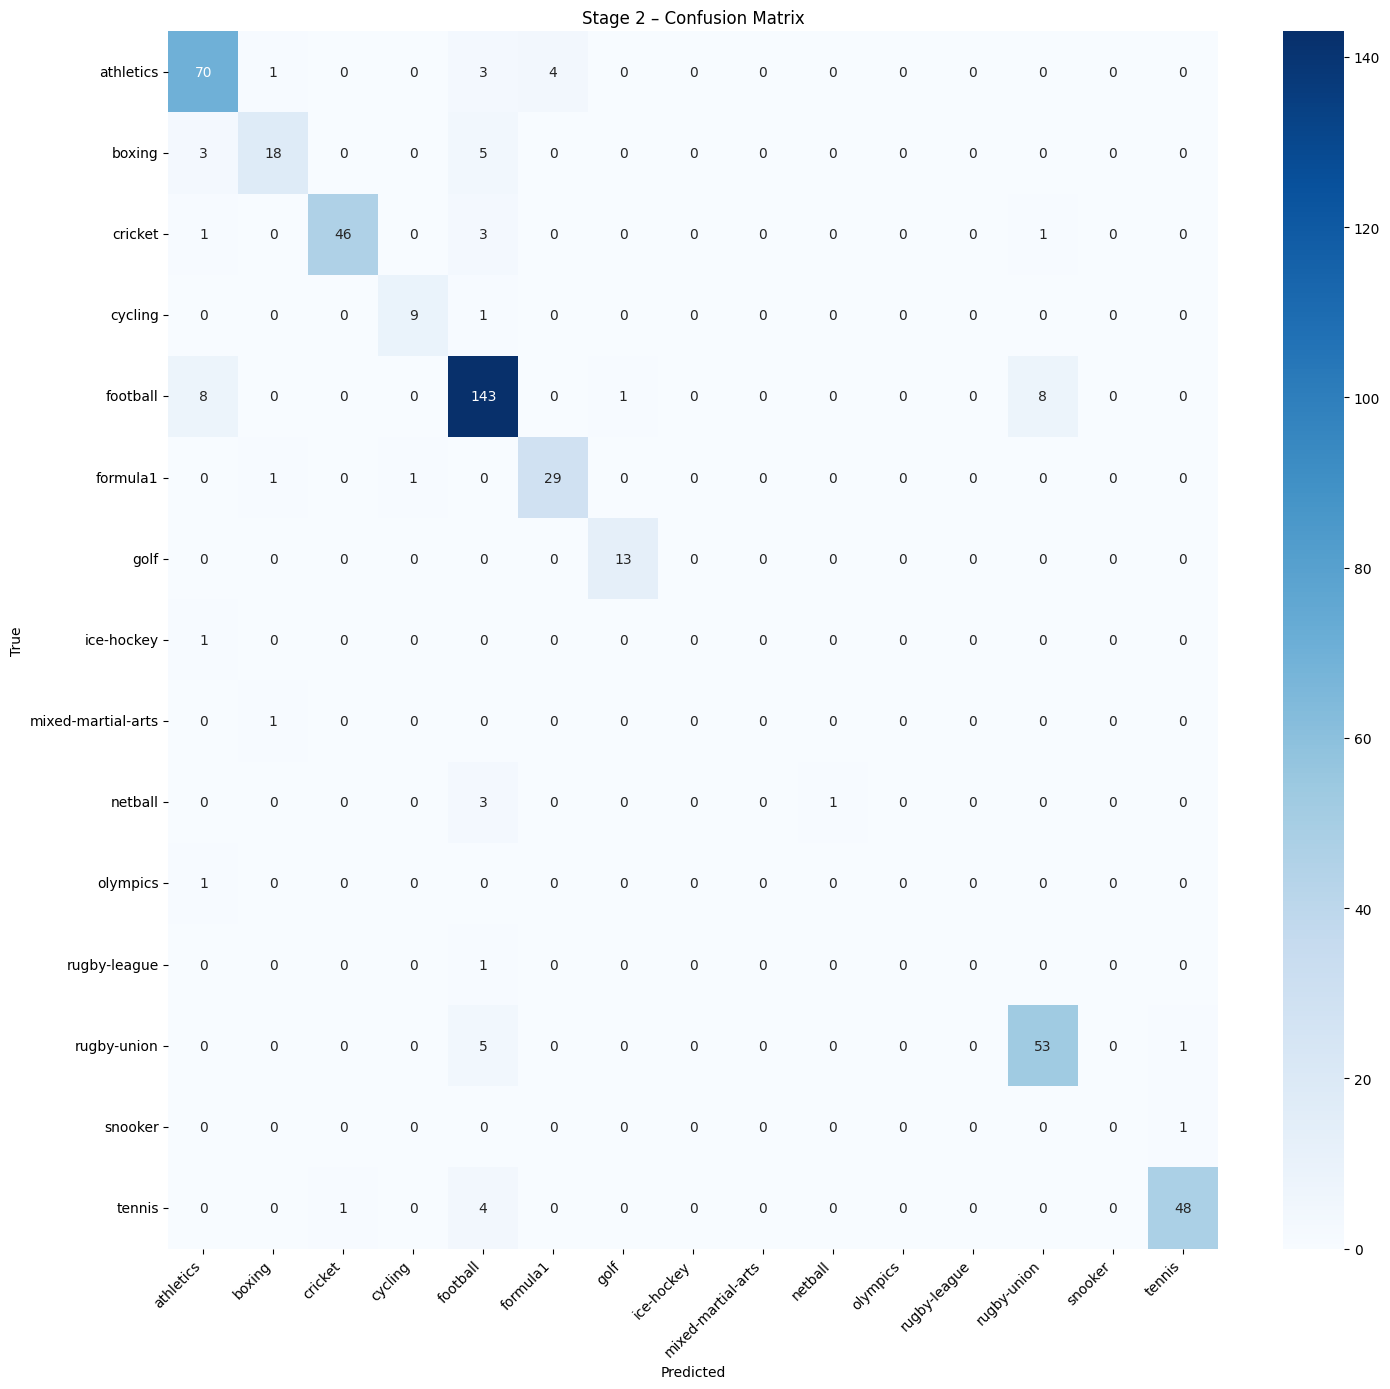

In [19]:
# Classification Report
unique_ids   = sorted(set(all_labels))
unique_names = [sport_id_to_label[i] for i in unique_ids]

print("\n── Classification Report ──")
print(classification_report(
    all_labels, all_preds,
    labels=unique_ids,          # solo le classi presenti nel test
    target_names=unique_names,
    zero_division=0,
))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds, labels=unique_ids)
fig, ax = plt.subplots(figsize=(max(6, len(unique_ids)), max(5, len(unique_ids) - 1)))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=unique_names,
    yticklabels=unique_names,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Stage 2 – Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()